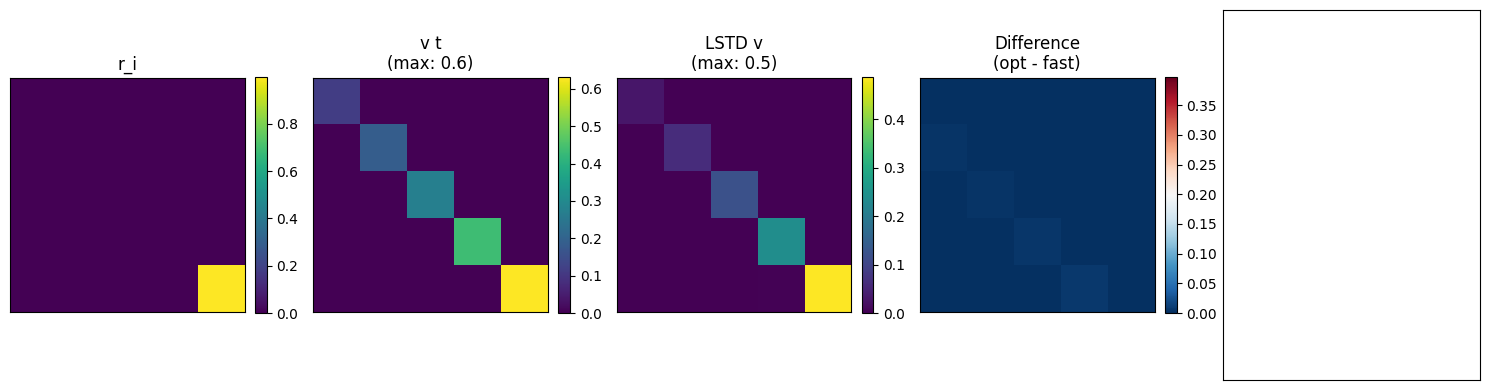

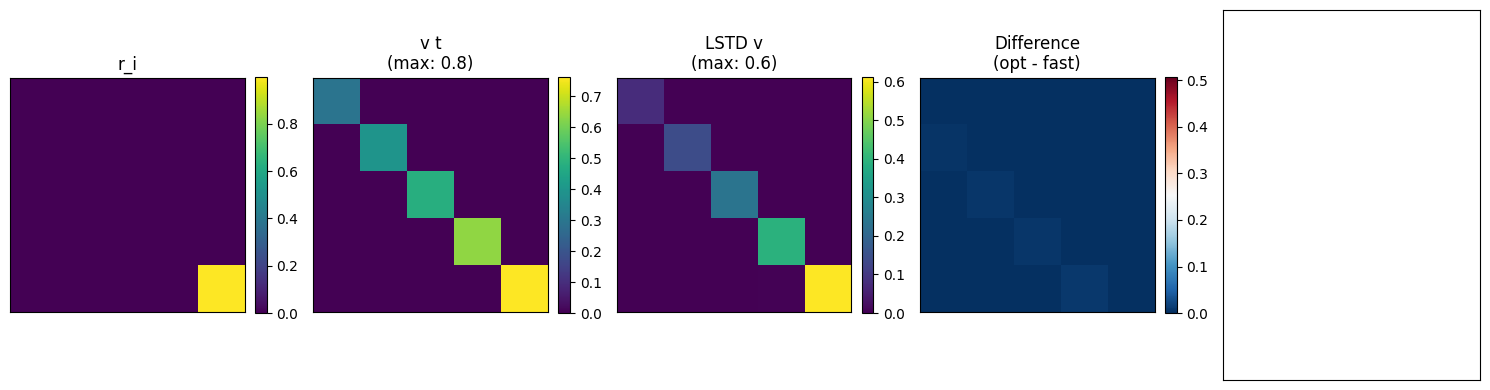

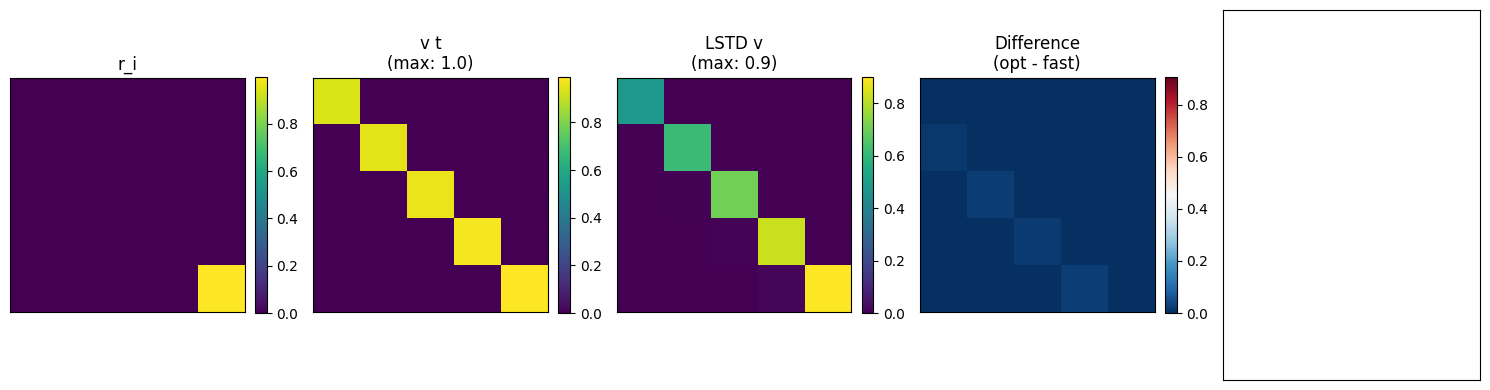

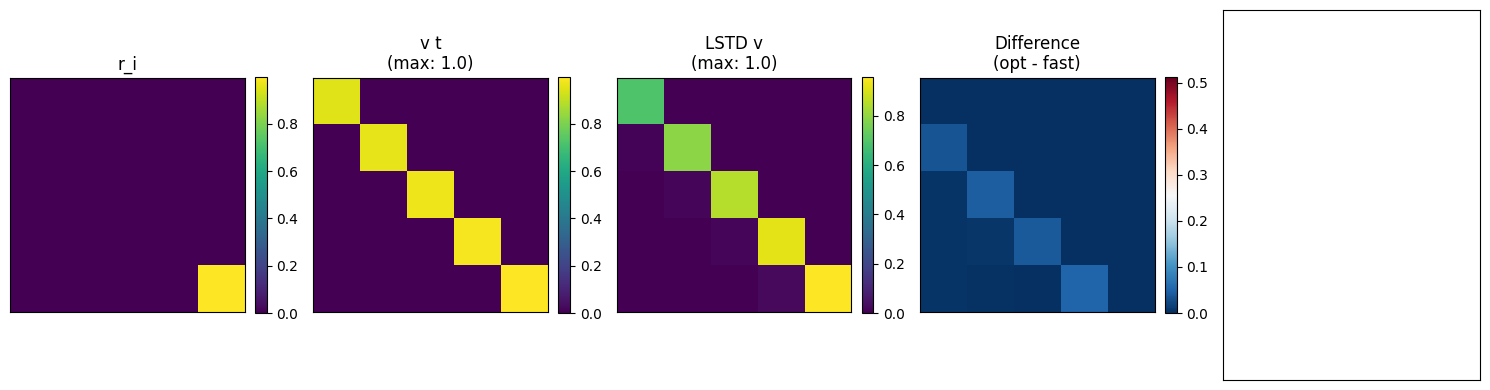

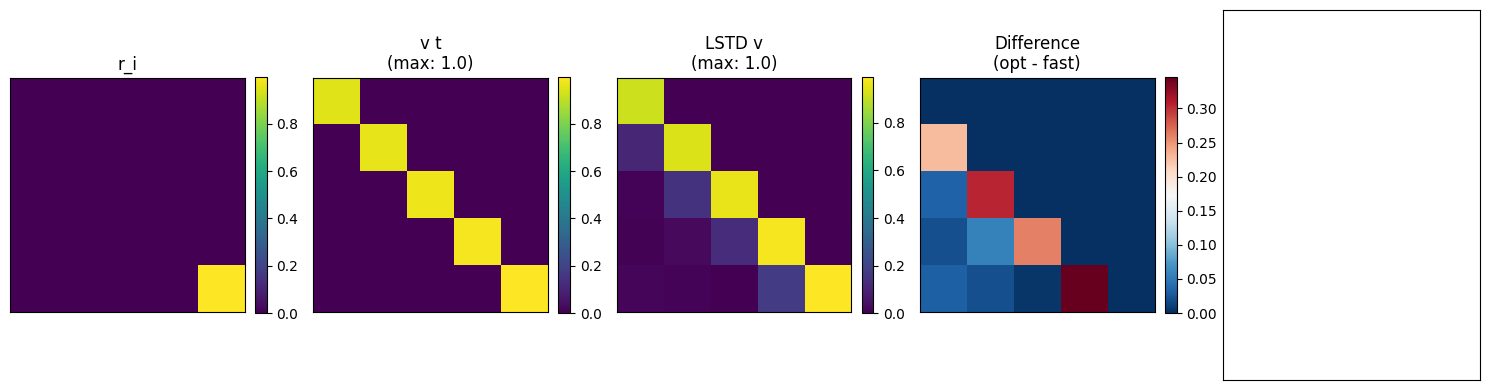

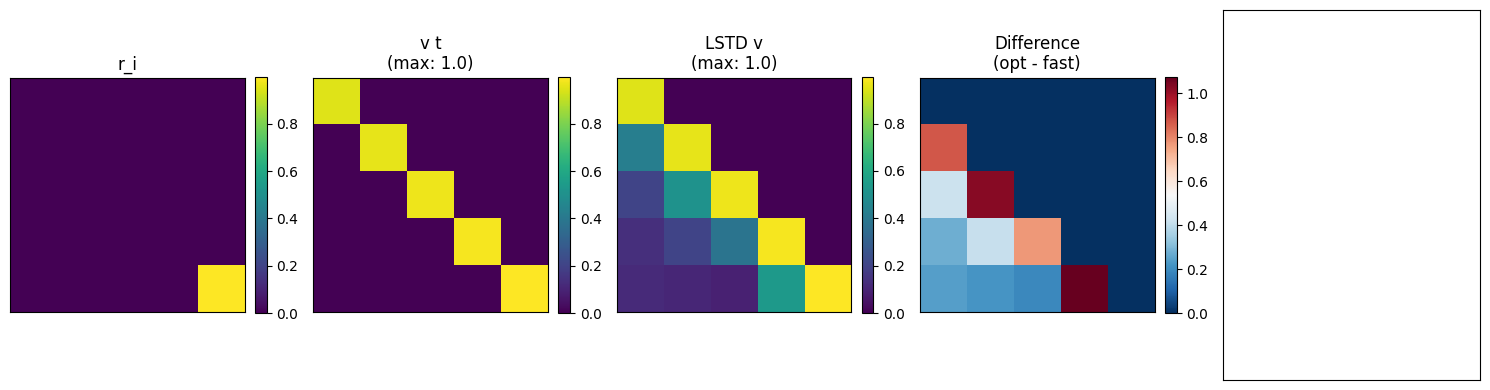

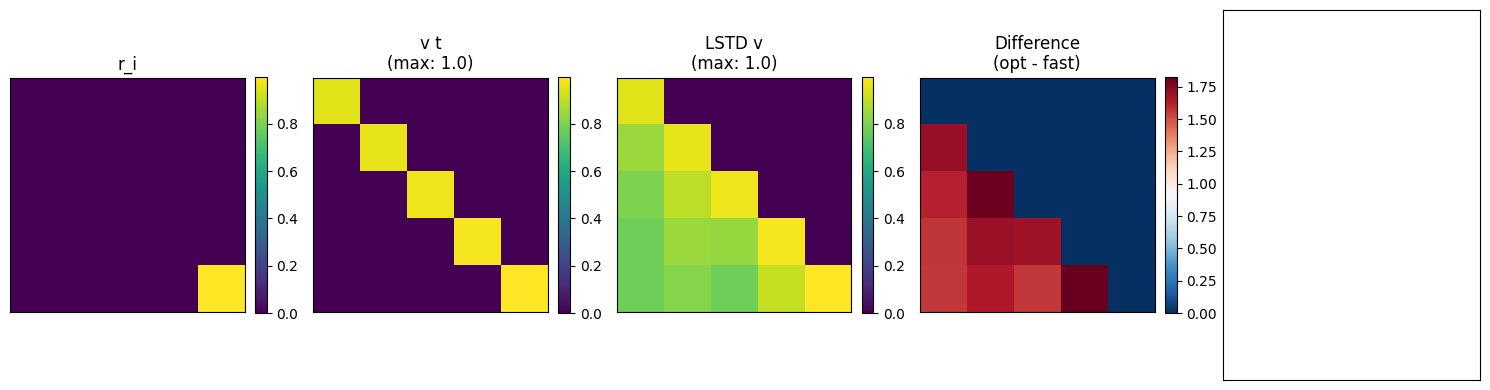

In [2]:
import jax.numpy as jnp
from utils import load_run_data
import matplotlib.pyplot as plt
from notebooks.mail import email_pdf
episodic_config, episodic_metrics = load_run_data('lstd_exact_val/20260118_143836', "DeepSea-bsuite", 'results')

N = episodic_config['DEEPSEA_SIZE']
reachable_mask = jnp.tril(jnp.ones((N,N)))

import matplotlib.pyplot as plt
import time

N = episodic_config['DEEPSEA_SIZE']
reachable_mask = jnp.tril(jnp.ones((N,N)))
Ts = [0,1,5,10,30,50, 200]
for T in Ts:
    fig, axes = plt.subplots(1, 5, figsize=(15, 4))
    # --- Plot 1: r_i ---
    im0 = axes[0].imshow(episodic_metrics['r_grid'][0][T] * reachable_mask, vmin=0)
    axes[0].set_title("r_i")
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    # --- Plot 2: v_i_fast (its own scale) ---
    im1 = axes[1].imshow(episodic_metrics['v_true_grid'][0][T] * reachable_mask, vmin=0)
    axes[1].set_title(f"v t\n(max: {jnp.max(episodic_metrics['v_true_grid'][0][T] * reachable_mask):.1f})")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    # --- Plot 3: v_i_opt (its own scale) ---
    im2 = axes[2].imshow(episodic_metrics['v_pred_grid'][0][T] * reachable_mask, vmin=0)
    axes[2].set_title(f"LSTD v\n(max: {jnp.max(episodic_metrics['v_pred_grid'][0][T] * reachable_mask):.1f})")
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    # --- Plot 4: Difference (opt - fast) ---
    diff = reachable_mask * (episodic_metrics['v_pred_grid'][0][T] - episodic_metrics['v_true_grid'][0][T])*2 
    im3 = axes[3].imshow(diff, cmap='RdBu_r', vmin=0, vmax=jnp.max(jnp.abs(diff)))
    axes[3].set_title("Difference\n(opt - fast)")
    plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

    # # # --- Plot 5: True v_i ---
    # im4 = axes[4].imshow(episodic_metrics['v_i'][0][T] * reachable_mask, vmin=0)
    # axes[4].set_title("True v_i")
    # plt.colorbar(im4, ax=axes[4], fraction=0.046, pad=0.04)

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
        
    plt.tight_layout()
    # plt.savefig(f'figures/grid_opt{T}.pdf')
    # # time.sleep(0.5)
    # # email_pdf(f'figures/grid_opt{T}.pdf')
    plt.show()


In [13]:
jnp.set_printoptions(precision=3)
episodic_metrics['v_true_grid'][200,5] * reachable_mask

Array([[ 0.944,  0.   ,  0.   ,  0.   ,  0.   ],
       [-0.008,  0.958,  0.   ,  0.   ,  0.   ],
       [-0.006, -0.006,  0.969,  0.   ,  0.   ],
       [-0.004, -0.004, -0.004,  0.984,  0.   ],
       [-0.002, -0.002, -0.002, -0.002,  0.996]], dtype=float32)

In [14]:
episodic_metrics['v_pred_grid'][200,5] * reachable_mask

Array([[ 5.100e-01,  0.000e+00,  0.000e+00,  0.000e+00,  0.000e+00],
       [-1.126e-03,  6.460e-01,  0.000e+00,  0.000e+00,  0.000e+00],
       [-2.452e-03,  1.573e-04,  7.278e-01,  0.000e+00,  0.000e+00],
       [-1.629e-03, -1.624e-03,  1.955e-03,  8.561e-01,  0.000e+00],
       [-7.927e-04, -1.800e-04, -1.346e-03,  1.263e-03,  9.107e-01]],      dtype=float32)